# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load Dataset

In [2]:
df = pd.read_csv("data.csv")
df.head()

,English,Tamil,Maths,Physics,Chemistry,Botany,Zoology,SocialScience,Total,Grade
0,73,53,95,74,72,47,61,64,539,C
1,40,49,48,75,52,79,48,46,437,D
2,55,50,65,49,52,74,65,89,499,C
3,42,64,81,45,49,74,77,46,478,D
4,53,87,83,59,59,90,60,95,586,B


# Data Cleaning

In [34]:
df = df.drop(['Student_ID', 'Student_Name'], axis=1, errors='ignore')
df.head()

,English,Tamil,Maths,Physics,Chemistry,Botany,Zoology,SocialScience,Total,Grade
0,73,53,95,74,72,47,61,64,539,C
1,40,49,48,75,52,79,48,46,437,D
2,55,50,65,49,52,74,65,89,499,C
3,42,64,81,45,49,74,77,46,478,D
4,53,87,83,59,59,90,60,95,586,B


# Info & Description

In [4]:
print(df.info())
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   English        1000 non-null   int64
 1   Tamil          1000 non-null   int64
 2   Maths          1000 non-null   int64
 3   Physics        1000 non-null   int64
 4   Chemistry      1000 non-null   int64
 5   Botany         1000 non-null   int64
 6   Zoology        1000 non-null   int64
 7   SocialScience  1000 non-null   int64
 8   Total          1000 non-null   int64
 9   Grade          1000 non-null   str  
dtypes: int64(9), str(1)
memory usage: 78.3 KB
None
           English        Tamil        Maths      Physics    Chemistry  \
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000   
mean     69.541000    70.219000    69.816000    70.727000    70.010000   
std      17.519111    17.866792    17.436748    17.544238    17.752663   
min      40.000000    40.000000    40.000000    40.00

# Feature Engineering

In [43]:
df['Average'] = df[['English','Tamil','Maths','Physics','Chemistry','Botany','Zoology','SocialScience']].mean(axis=1)
def grade(avg):
    if avg >= 90:
        return 'A'
    elif avg >= 75:
        return 'B'
    elif avg >= 60:
        return 'C'
    elif avg >= 50:
        return 'D'
    else:
        return 'F'

df['Grade'] = df['Average'].apply(grade)
df.head()

,English,Tamil,Maths,Physics,Chemistry,Botany,Zoology,SocialScience,Total,Grade,Average
0,73,53,95,74,72,47,61,64,539,C,67.375
1,40,49,48,75,52,79,48,46,437,D,54.625
2,55,50,65,49,52,74,65,89,499,C,62.375
3,42,64,81,45,49,74,77,46,478,D,59.750
4,53,87,83,59,59,90,60,95,586,C,73.250


# Basic Statistics

In [42]:
marks_array = df[['English','Tamil','Maths','Physics','Chemistry','Botany','Zoology','SocialScience']].values
print("Mean:", np.mean(marks_array))
print("Median:", np.median(marks_array))
print("Standard Deviation:", np.std(marks_array))

Mean: 69.994875
Median: 70.0
Standard Deviation: 17.623729705552538


# Subject Averages

In [37]:
subject_means = df[['English','Tamil','Maths','Physics','Chemistry','Botany','Zoology','SocialScience']].mean()
print(subject_means)

English          69.541
Tamil            70.219
Maths            69.816
Physics          70.727
Chemistry        70.010
Botany           69.944
Zoology          70.280
SocialScience    69.422
dtype: float64


# Top Students

In [11]:
top_students = df.sort_values(by='Total', ascending=False).head(10)
top_students[['Total']]

,Total
653,735
869,701
601,696
316,695
642,692
46,687
393,684
647,680
569,678
95,675


# Bar Chart

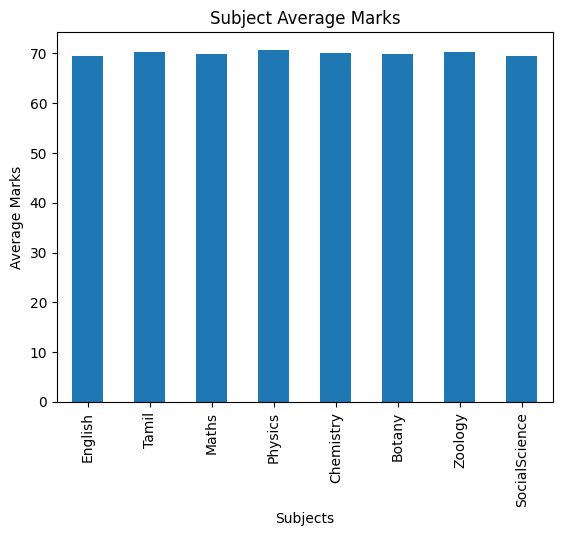

In [38]:
subject_means.plot(kind='bar')
plt.title("Subject Average Marks")
plt.xlabel("Subjects")
plt.ylabel("Average Marks")
plt.show()

# Grade Distribution

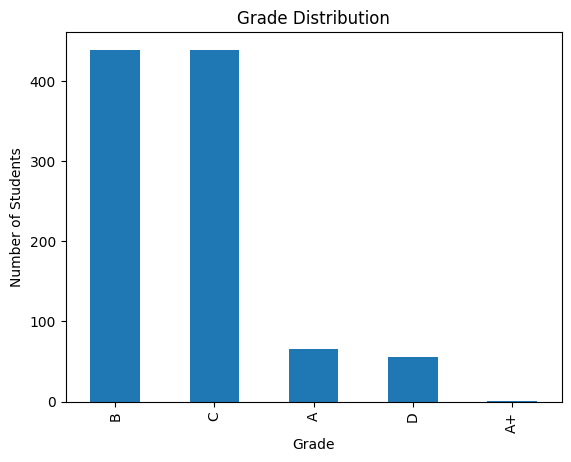

In [15]:
df['Grade'].value_counts().plot(kind='bar')
plt.title("Grade Distribution")
plt.xlabel("Grade")
plt.ylabel("Number of Students")
plt.show()

# Histogram

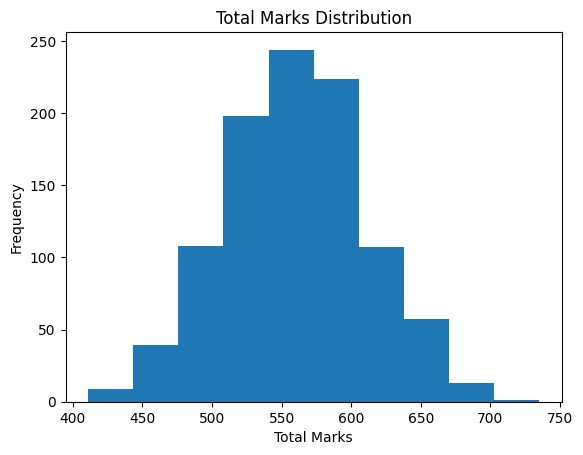

In [17]:
plt.hist(df['Total'], bins=10)
plt.title("Total Marks Distribution")
plt.xlabel("Total Marks")
plt.ylabel("Frequency")
plt.show()

# Correlation

In [19]:
correlation = df.corr(numeric_only=True)
print(correlation)

                English     Tamil     Maths   Physics  Chemistry    Botany  \
English        1.000000  0.012032  0.056826 -0.028478   0.059464  0.004647   
Tamil          0.012032  1.000000 -0.015509  0.037806   0.075353 -0.021325   
Maths          0.056826 -0.015509  1.000000 -0.001944  -0.021796  0.046443   
Physics       -0.028478  0.037806 -0.001944  1.000000  -0.027721  0.032602   
Chemistry      0.059464  0.075353 -0.021796 -0.027721   1.000000 -0.013654   
Botany         0.004647 -0.021325  0.046443  0.032602  -0.013654  1.000000   
Zoology       -0.027696 -0.009459 -0.040949 -0.016485  -0.025390  0.001030   
SocialScience  0.036247  0.018866 -0.003451  0.014693   0.030785 -0.058160   
Total          0.386060  0.387969  0.351463  0.350957   0.378522  0.343087   

                Zoology  SocialScience     Total  
English       -0.027696       0.036247  0.386060  
Tamil         -0.009459       0.018866  0.387969  
Maths         -0.040949      -0.003451  0.351463  
Physics       -

# Box Plot

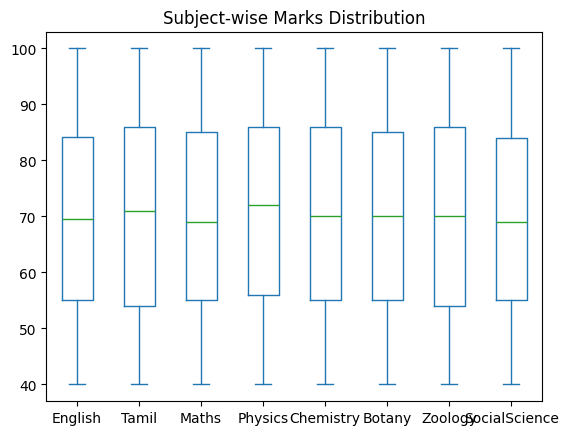

In [41]:
subjects = ['English','Tamil','Maths','Physics','Chemistry','Botany','Zoology','SocialScience']
df[subjects].plot(kind='box')
plt.title("Subject-wise Marks Distribution")
plt.show()

# Pie Chart

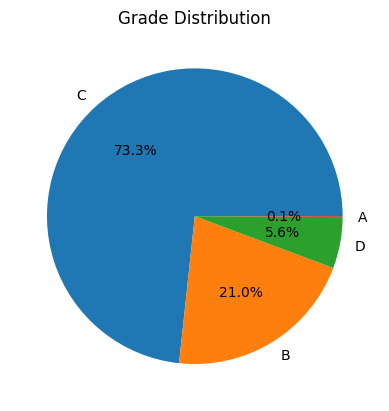

In [40]:
grade_counts = df['Grade'].value_counts()
plt.pie(grade_counts, labels=grade_counts.index, autopct='%1.1f%%')
plt.title("Grade Distribution")
plt.show()

# Scatter Plot

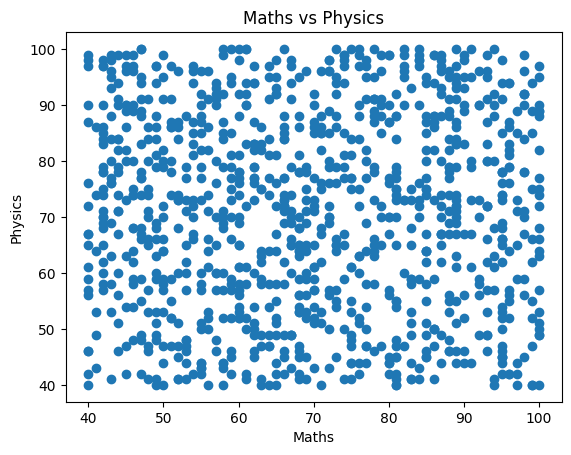

In [44]:
plt.scatter(df['Maths'], df['Physics'])
plt.title("Maths vs Physics")
plt.xlabel("Maths")
plt.ylabel("Physics")
plt.show()

# Machine Learning Models

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
X = df[['English','Tamil','Maths','Physics','Chemistry','Botany','Zoology','SocialScience']]
y_total = df['Total']
y_grade = df['Grade']
X_train, X_test, y_train_total, y_test_total = train_test_split(X, y_total, test_size=0.2)
_, _, y_train_grade, y_test_grade = train_test_split(X, y_grade, test_size=0.2)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
linear_model = LinearRegression()
logistic_model = LogisticRegression(max_iter=2000)
linear_model.fit(X_train_scaled, y_train_total)
logistic_model.fit(X_train_scaled, y_train_grade)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

# Model Evaluation

In [49]:
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score
y_pred_total = linear_model.predict(X_test_scaled)
print("MAE:", mean_absolute_error(y_test_total, y_pred_total))
print("R2 Score:", r2_score(y_test_total, y_pred_total))
y_pred_grade = logistic_model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test_grade, y_pred_grade))

MAE: 4.177991286269389e-14
R2 Score: 1.0
Accuracy: 0.775


# Prediction System

In [52]:
print("Prediction System")
choice = input("Enter 'marks' or 'grade': ").lower()
X = df[['English','Tamil','Maths','Physics','Chemistry','Botany','Zoology','SocialScience']]
if choice == "marks":
    values = []
    for col in X.columns:
        val = float(input(f"{col}: "))
        values.append(val)
    input_df = pd.DataFrame([values], columns=X.columns)
    input_scaled = scaler.transform(input_df)
    total_pred = linear_model.predict(input_scaled)[0]
    grade_pred = logistic_model.predict(input_scaled)[0]
    cgpa = (total_pred / df['Total'].max()) * 10
    print(f"\nPredicted Total: {total_pred:.2f}")
    print(f"Predicted Grade: {grade_pred}")
    print(f"Estimated CGPA: {cgpa:.2f}")
elif choice == "grade":
    grade_input = input("Enter Grade (A/B/C/D/F): ").upper()
    filtered = df[df['Grade'] == grade_input]
    if len(filtered) == 0:
        print("Invalid Grade!")
    else:
        avg_total = filtered['Total'].mean()
        cgpa = (avg_total / df['Total'].max()) * 10
        print(f"\nEstimated Total: {avg_total:.2f}")
        print(f"Estimated CGPA: {cgpa:.2f}")
        print(f"Overall Grade: {grade_input}")

Prediction System


Enter 'marks' or 'grade':  grade
Enter Grade (A/B/C/D/F):  b



Estimated Total: 628.76
Estimated CGPA: 8.55
Overall Grade: B
